In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay,
                             precision_recall_curve, auc)
from sklearn.feature_selection import mutual_info_classif, chi2, f_classif
from sklearn.preprocessing import MinMaxScaler
from matplotlib.patches import Patch
!pip install lime
from lime.lime_tabular import LimeTabularExplainer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=67bfae968b3449733dee9b070c15e7207ac6803bcea102cea85cdb8453bf6578
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


#Load data

In [2]:
import kagglehub

path = kagglehub.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease")
print("Path to dataset files:", path)

data = pd.read_csv(os.path.join(path, '2022', 'heart_2022_no_nans.csv'))
print("Shape:", data.shape)
data.head()

100%|██████████| 21.4M/21.4M [00:00<00:00, 67.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/versions/6
Shape: (246022, 40)


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,4.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.60,71.67,27.99,No,No,Yes,Yes,"Yes, received Tdap",No,No
1,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,...,1.78,95.25,30.13,No,No,Yes,Yes,"Yes, received tetanus shot but not sure what type",No,No
2,Alabama,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,"6 or more, but not all",No,...,1.85,108.86,31.66,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
3,Alabama,Female,Fair,5.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,None of them,No,...,1.70,90.72,31.32,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
4,Alabama,Female,Good,3.0,15.0,Within past year (anytime less than 12 months ...,Yes,5.0,1 to 5,No,...,1.55,79.38,33.07,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [3]:
pd.set_option('display.max_columns', None)
print("Shape:", data.shape)
print("\nDtypes:\n", data.dtypes)
print("\nMissing values:", data.isnull().sum().sum())
data.describe()

Shape: (246022, 40)

Dtypes:
 State                         object
Sex                           object
GeneralHealth                 object
PhysicalHealthDays           float64
MentalHealthDays             float64
LastCheckupTime               object
PhysicalActivities            object
SleepHours                   float64
RemovedTeeth                  object
HadHeartAttack                object
HadAngina                     object
HadStroke                     object
HadAsthma                     object
HadSkinCancer                 object
HadCOPD                       object
HadDepressiveDisorder         object
HadKidneyDisease              object
HadArthritis                  object
HadDiabetes                   object
DeafOrHardOfHearing           object
BlindOrVisionDifficulty       object
DifficultyConcentrating       object
DifficultyWalking             object
DifficultyDressingBathing     object
DifficultyErrands             object
SmokerStatus                  object
ECigaret

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000,246022.000000
mean,4.119026,4.167140,7.021331,1.705150,83.615179,28.668136
std,8.405844,8.102687,1.440681,0.106654,21.323156,6.513973
min,0.000000,0.000000,1.000000,0.910000,28.120000,12.020000
25%,0.000000,0.000000,6.000000,1.630000,68.040000,24.270000
50%,0.000000,0.000000,7.000000,1.700000,81.650000,27.460000
75%,3.000000,4.000000,8.000000,1.780000,95.250000,31.890000
max,30.000000,30.000000,24.000000,2.410000,292.570000,97.650000


#Outlier detection

In [4]:
numeric_cols = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours',
                'HeightInMeters', 'WeightInKilograms', 'BMI']

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((data[col] < lower) | (data[col] > upper)).sum()
    pct = round(n / len(data) * 100, 2)
    print(f"{col}: {n} outliers ({pct}%) | range [{round(lower,2)}, {round(upper,2)}]")

PhysicalHealthDays: 38810 outliers (15.78%) | range [-4.5, 7.5]
MentalHealthDays: 32714 outliers (13.3%) | range [-6.0, 10.0]
SleepHours: 3488 outliers (1.42%) | range [3.0, 11.0]
HeightInMeters: 830 outliers (0.34%) | range [1.4, 2.01]
WeightInKilograms: 5940 outliers (2.41%) | range [27.23, 136.06]
BMI: 7563 outliers (3.07%) | range [12.84, 43.32]


#Value counts (categorical only)

In [5]:
for col in data.select_dtypes(include='object').columns:
    print(f"Value counts for '{col}':")
    print(data[col].value_counts())
    print("-" * 40)

Value counts for 'State':
State
Washington              15000
Maryland                 9165
Minnesota                9161
Ohio                     8995
New York                 8923
Texas                    7408
Florida                  7315
Kansas                   6145
Wisconsin                6126
Maine                    6013
Iowa                     5672
Hawaii                   5596
Virginia                 5565
Indiana                  5502
South Carolina           5471
Massachusetts            5465
Arizona                  5462
Utah                     5373
Michigan                 5370
Colorado                 5159
Nebraska                 5107
California               5096
Connecticut              5053
Georgia                  4978
Vermont                  4845
South Dakota             4405
Montana                  4264
Missouri                 4195
New Jersey               3967
New Hampshire            3756
Puerto Rico              3589
Idaho                    3468
Alaska  

#Target distribution

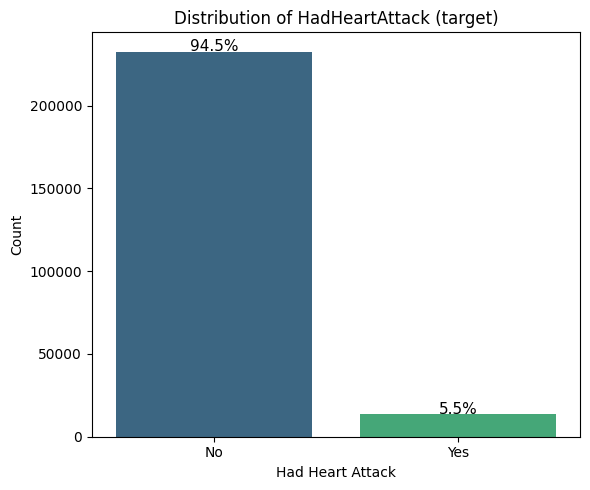

HadHeartAttack
No     232587
Yes     13435
Name: count, dtype: int64

Class imbalance ratio: 17.3:1


In [6]:
plt.figure(figsize=(6, 5))
sns.countplot(x='HadHeartAttack', data=data, palette='viridis')
plt.title('Distribution of HadHeartAttack (target)')
plt.xlabel('Had Heart Attack')
plt.ylabel('Count')

total = len(data)
for p in plt.gca().patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    plt.gca().annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height() + 500),
                       ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(data['HadHeartAttack'].value_counts())
print(f"\nClass imbalance ratio: {round(232587/13435, 1)}:1")

# Statistical summary

In [7]:
print(data[numeric_cols].agg(['mean', 'median', 'std', 'skew', 'kurt']).round(2))

        PhysicalHealthDays  MentalHealthDays  SleepHours  HeightInMeters  \
mean                  4.12              4.17        7.02            1.71   
median                0.00              0.00        7.00            1.70   
std                   8.41              8.10        1.44            0.11   
skew                  2.28              2.22        0.56            0.03   
kurt                  3.97              3.86        7.21            0.01   

        WeightInKilograms    BMI  
mean                83.62  28.67  
median              81.65  27.46  
std                 21.32   6.51  
skew                 1.02   1.33  
kurt                 2.34   3.90  


#Univariate: histograms

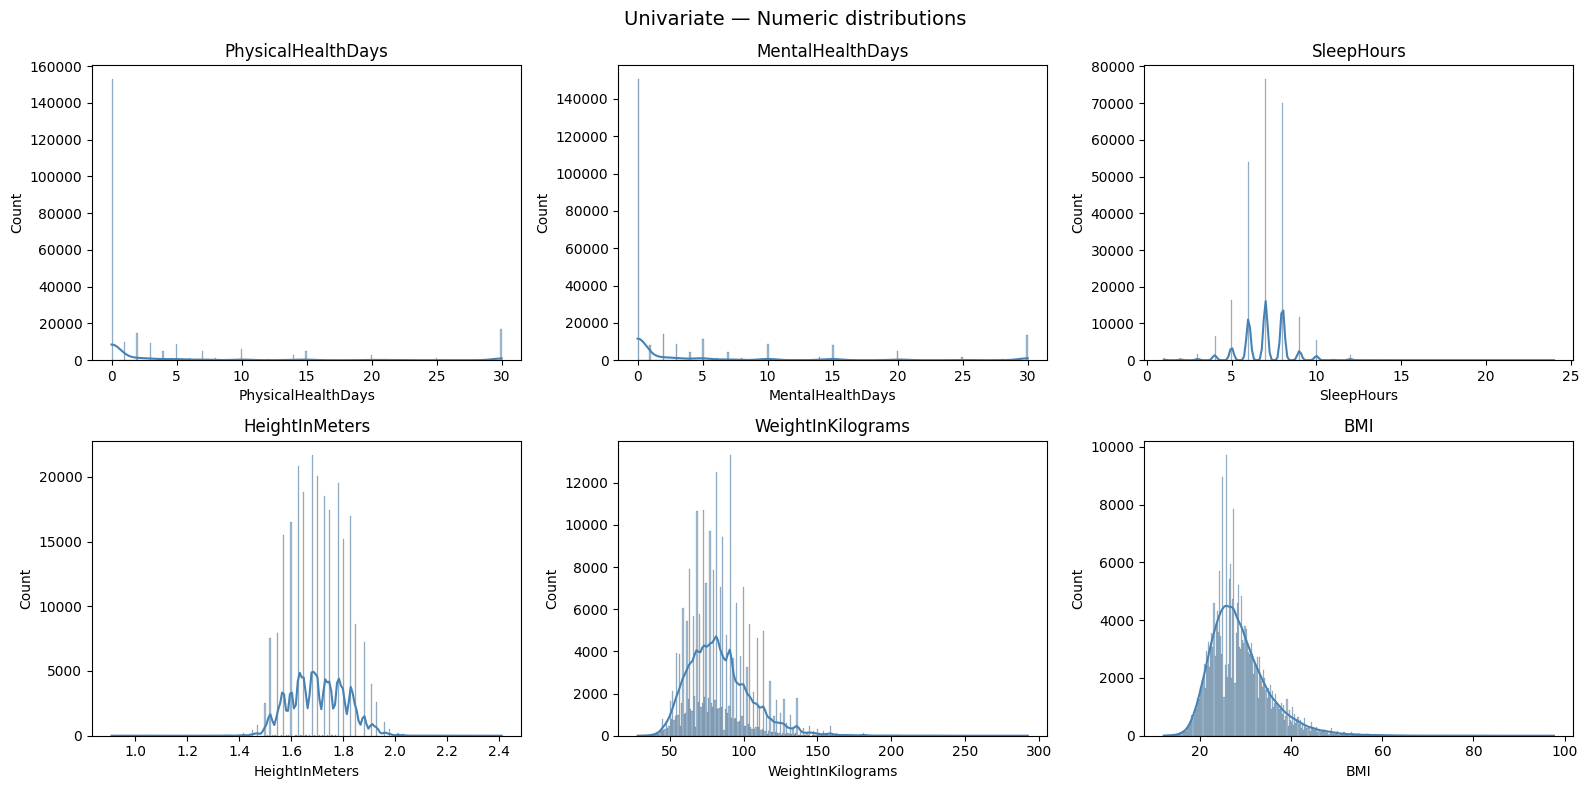

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(data[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Univariate — Numeric distributions', fontsize=14)
plt.tight_layout()
plt.show()

#Univariate: boxplots

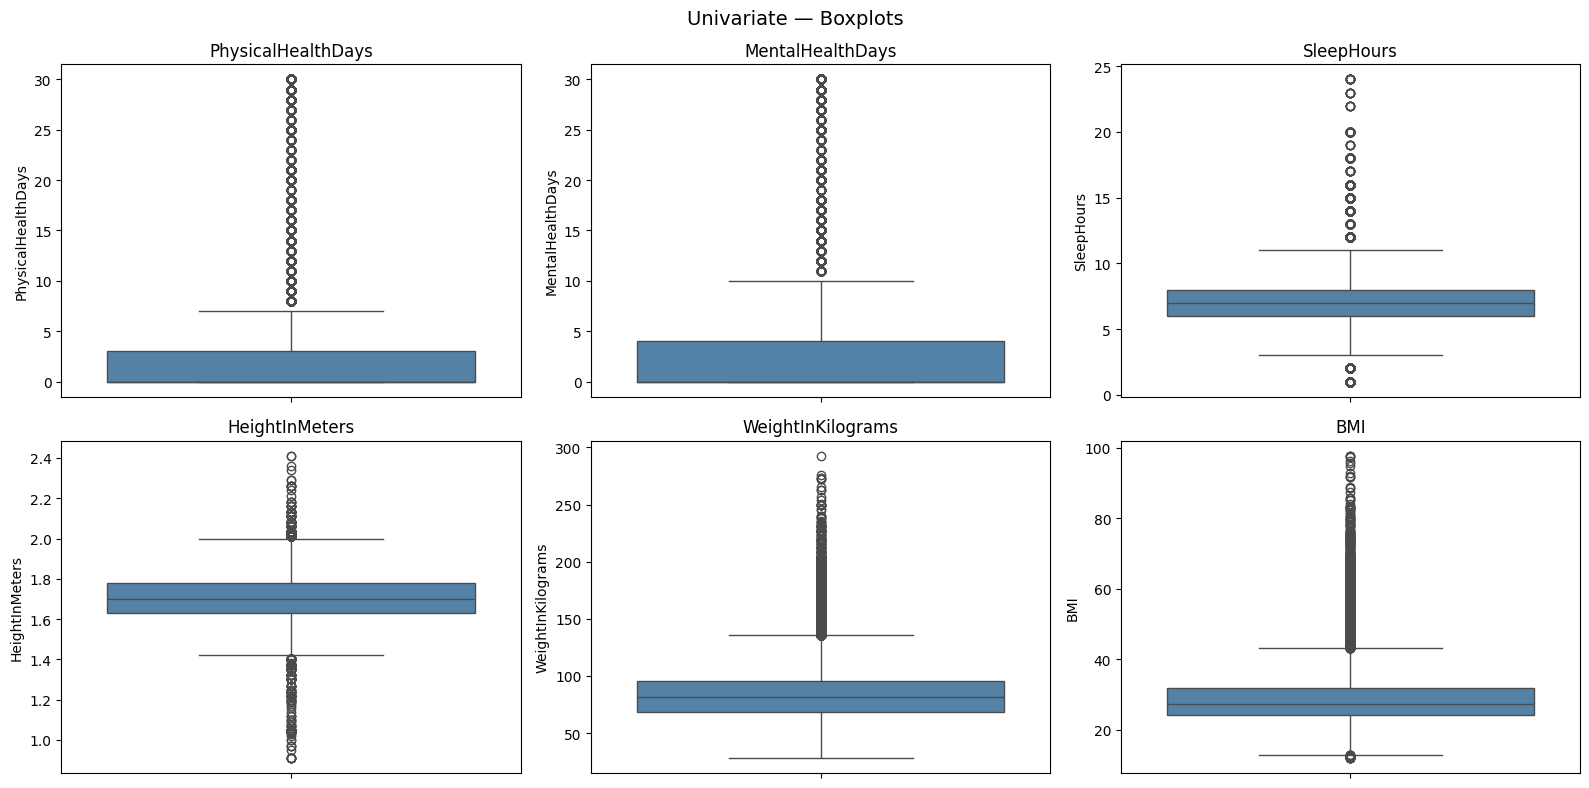

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=data[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Univariate — Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

# violin plots

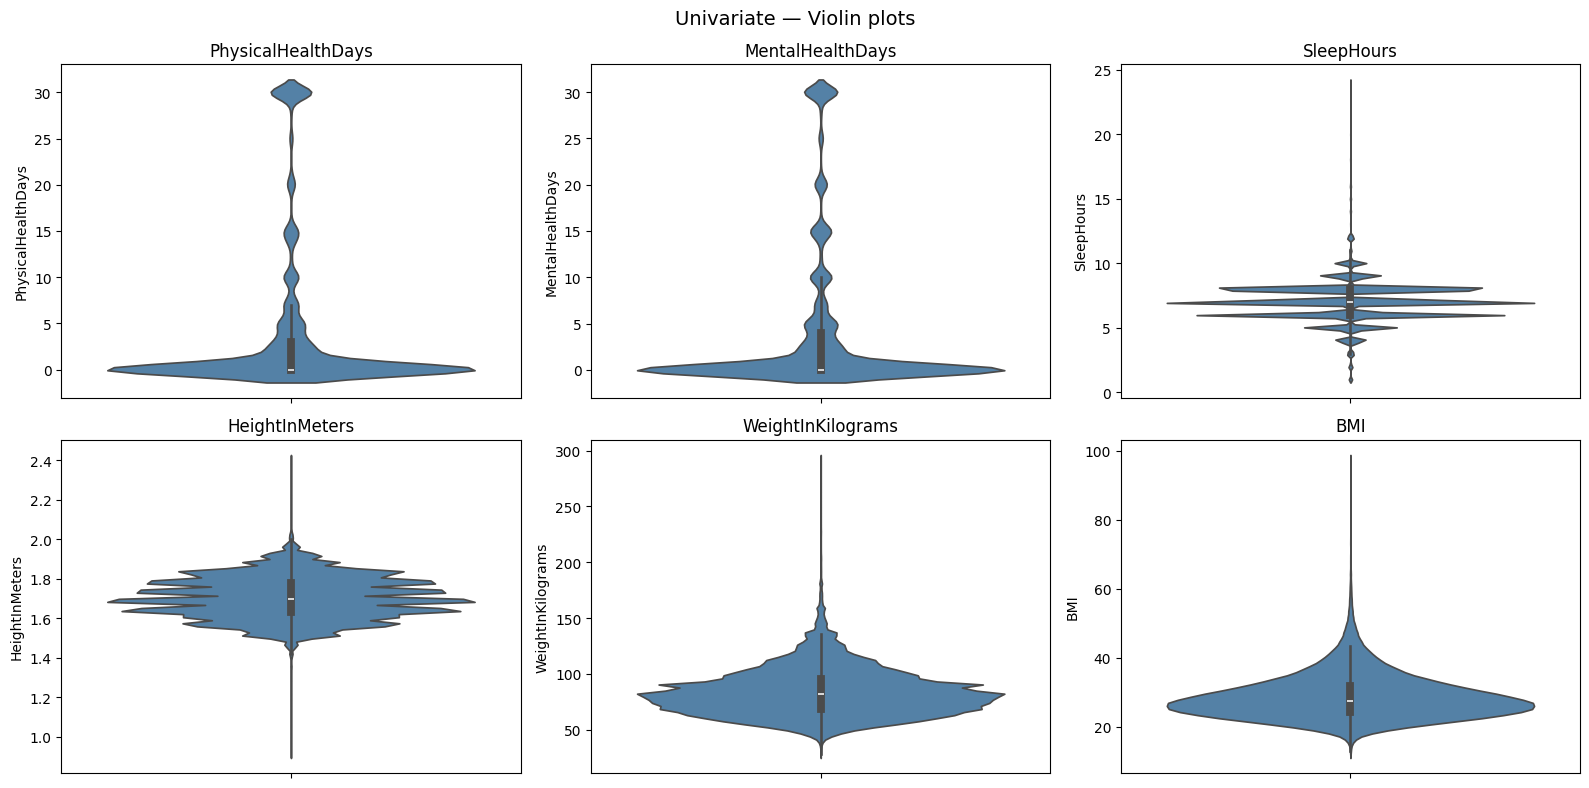

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.violinplot(y=data[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Univariate — Violin plots', fontsize=14)
plt.tight_layout()
plt.show()

#Univariate: categorical countplots

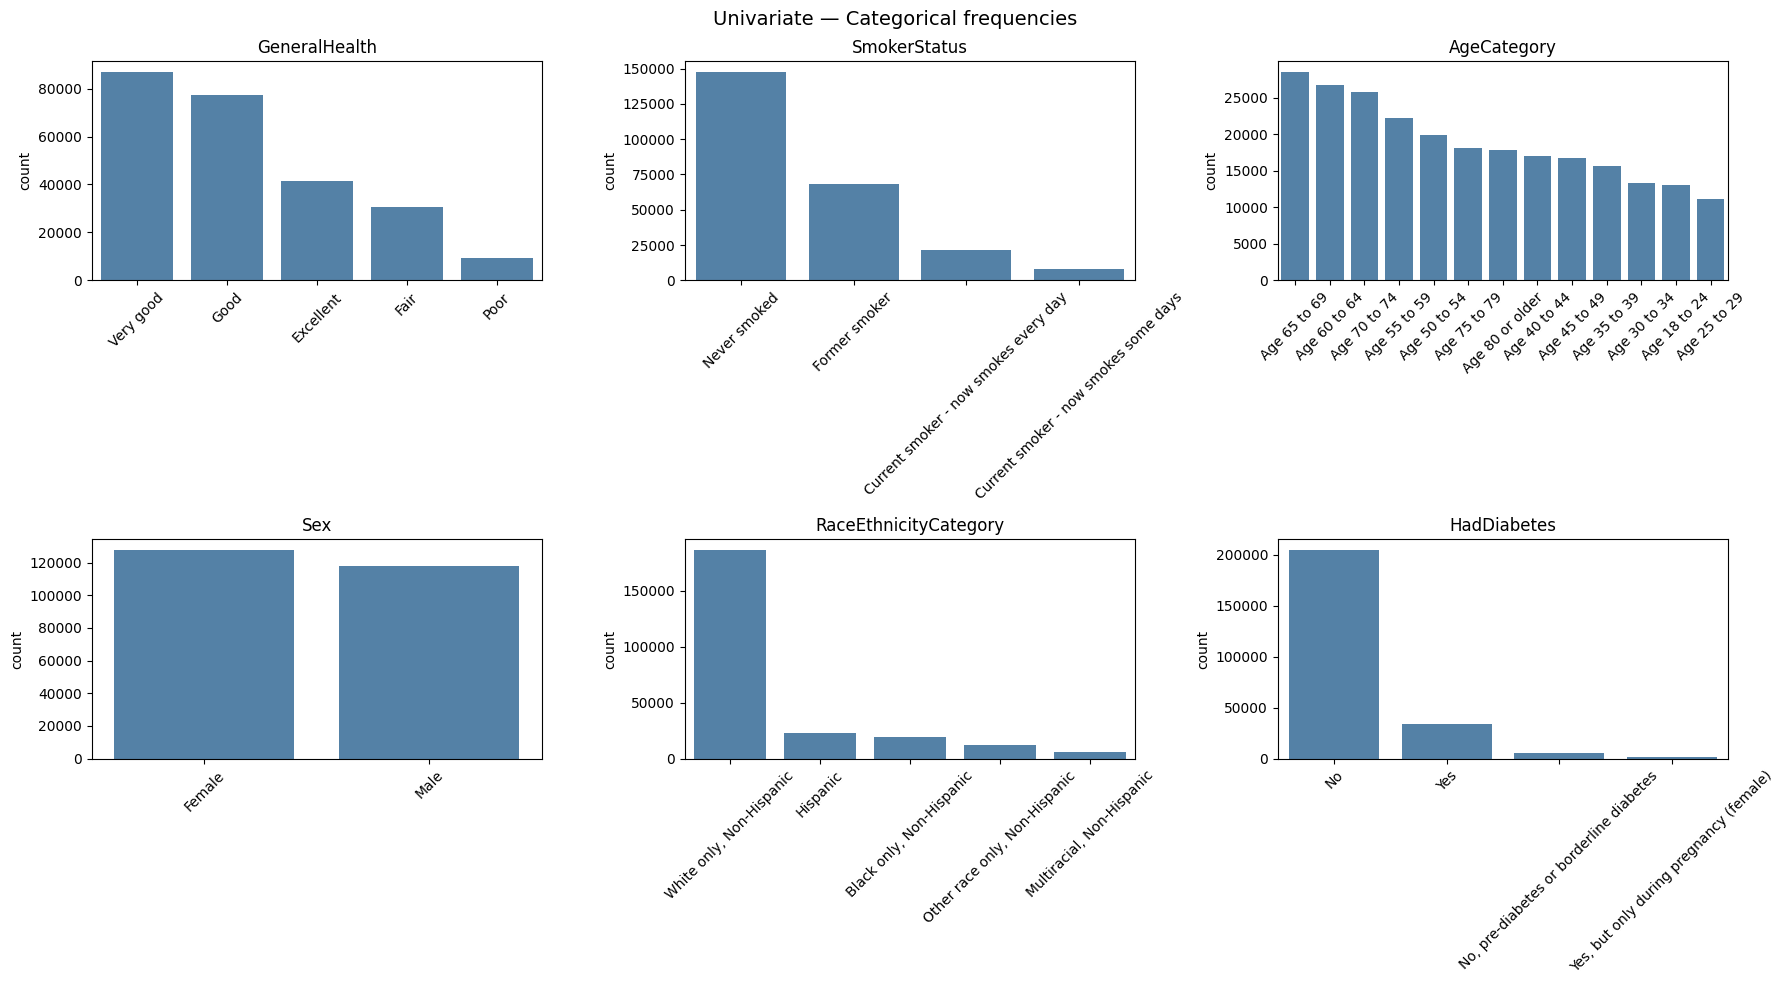

In [11]:
cat_plot_cols = ['GeneralHealth', 'SmokerStatus', 'AgeCategory',
                 'Sex', 'RaceEthnicityCategory', 'HadDiabetes']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), cat_plot_cols):
    order = data[col].value_counts().index
    sns.countplot(x=col, data=data, order=order, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
plt.suptitle('Univariate — Categorical frequencies', fontsize=14)
plt.tight_layout()
plt.show()

#Multivariate: numeric vs HadHeartAttack

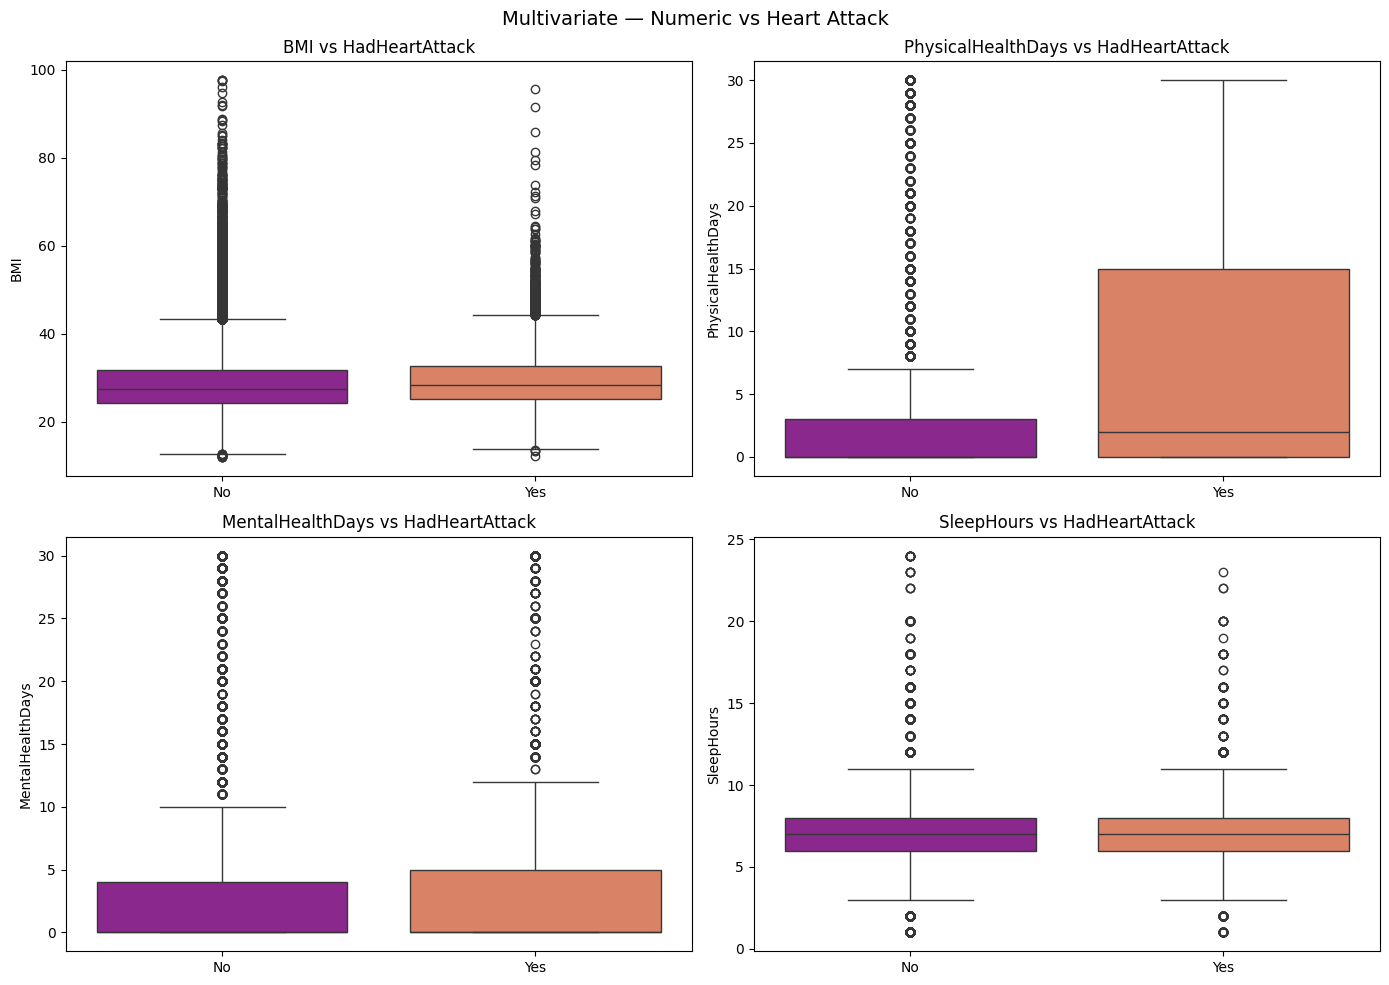

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['BMI', 'PhysicalHealthDays',
                                     'MentalHealthDays', 'SleepHours']):
    sns.boxplot(x='HadHeartAttack', y=col, data=data, palette='plasma', ax=ax)
    ax.set_title(f'{col} vs HadHeartAttack')
    ax.set_xlabel('')
plt.suptitle('Multivariate — Numeric vs Heart Attack', fontsize=14)
plt.tight_layout()
plt.show()

#Multivariate: categorical vs HadHeartAttack

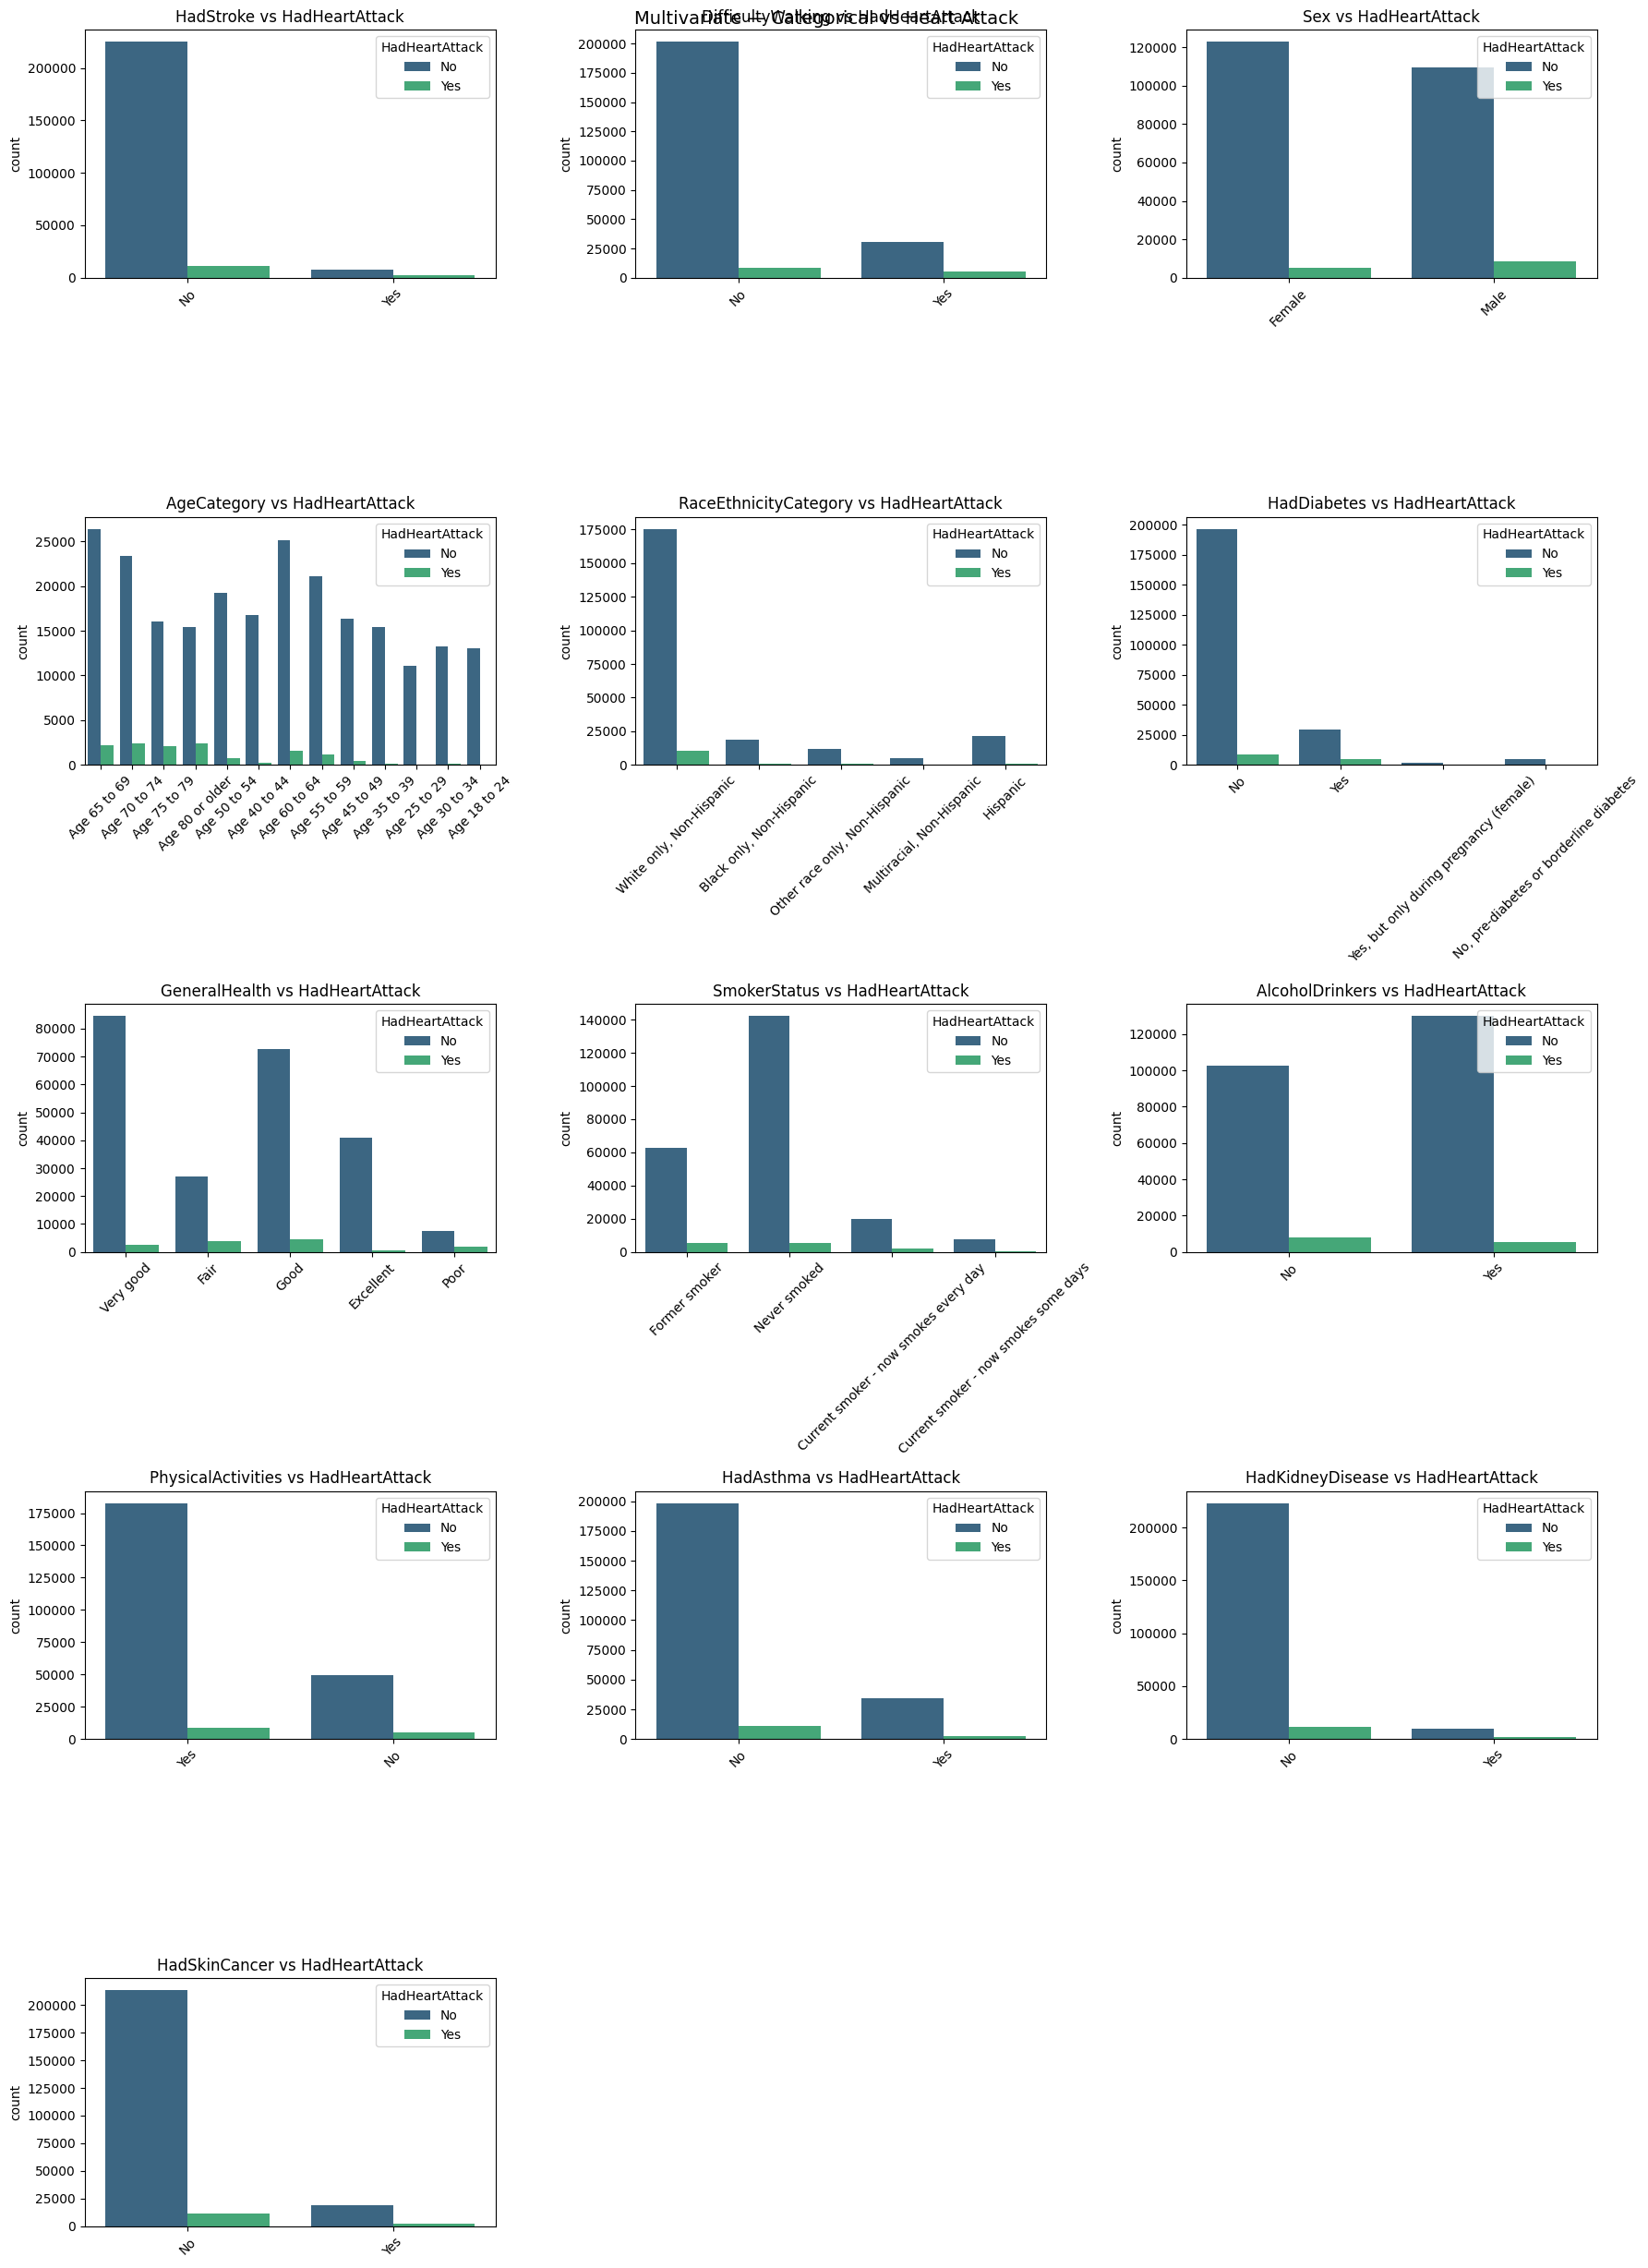

In [13]:
categorical_cols = ['HadStroke', 'DifficultyWalking', 'Sex', 'AgeCategory',
                    'RaceEthnicityCategory', 'HadDiabetes', 'GeneralHealth',
                    'SmokerStatus', 'AlcoholDrinkers', 'PhysicalActivities',
                    'HadAsthma', 'HadKidneyDisease', 'HadSkinCancer']

n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='HadHeartAttack', data=data,
                  palette='viridis', ax=axes[i])
    axes[i].set_title(f'{col} vs HadHeartAttack')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Multivariate — Categorical vs Heart Attack', fontsize=14)
plt.tight_layout()
plt.show()

#Multivariate: correlation heatmap

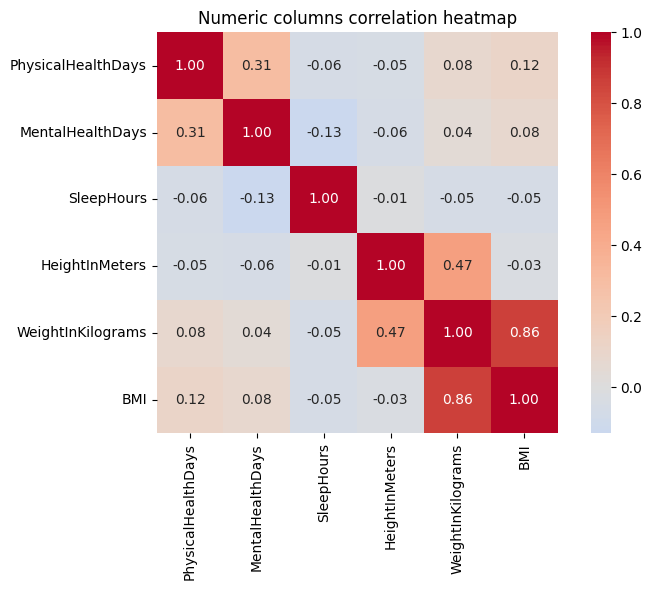

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Numeric columns correlation heatmap')
plt.tight_layout()
plt.show()

#Multivariate: pairplot

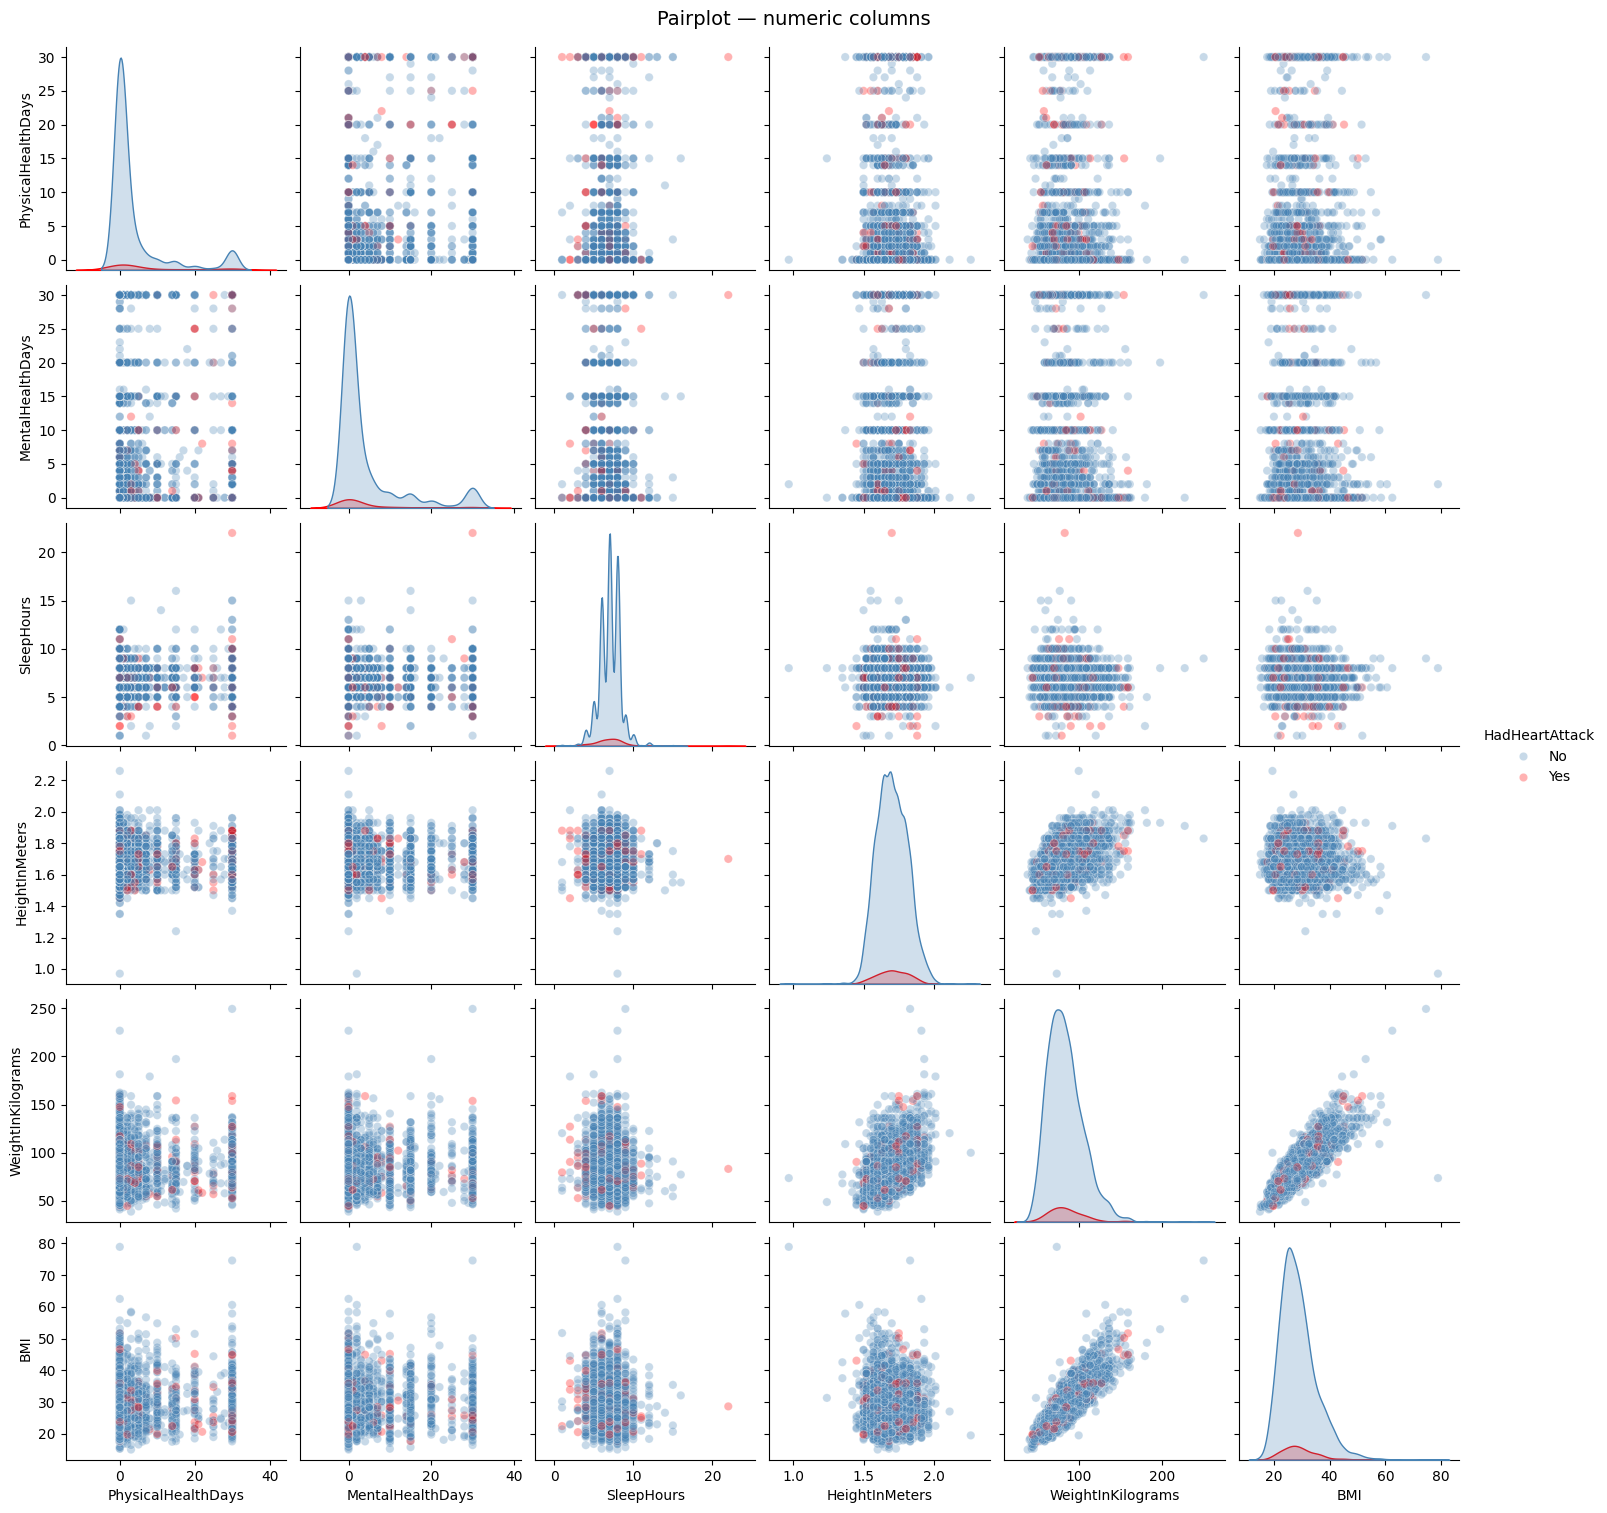

In [15]:
sample = data[numeric_cols + ['HadHeartAttack']].sample(3000, random_state=42).copy()

sns.pairplot(sample, hue='HadHeartAttack',
             palette={'Yes': 'red', 'No': 'steelblue'},
             plot_kws={'alpha': 0.3}, diag_kind='kde')
plt.suptitle('Pairplot — numeric columns', y=1.01, fontsize=14)
plt.show()

#Multivariate: joint distribution plot

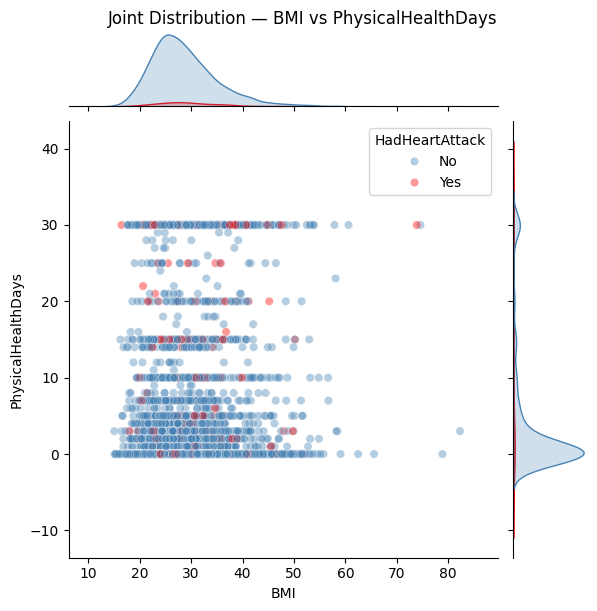

In [16]:
sns.jointplot(data=data.sample(5000, random_state=42),
              x='BMI', y='PhysicalHealthDays',
              hue='HadHeartAttack',
              palette={'Yes': 'red', 'No': 'steelblue'},
              alpha=0.4)
plt.suptitle('Joint Distribution — BMI vs PhysicalHealthDays', y=1.01)
plt.show()

#Multivariate: parallel coordinates

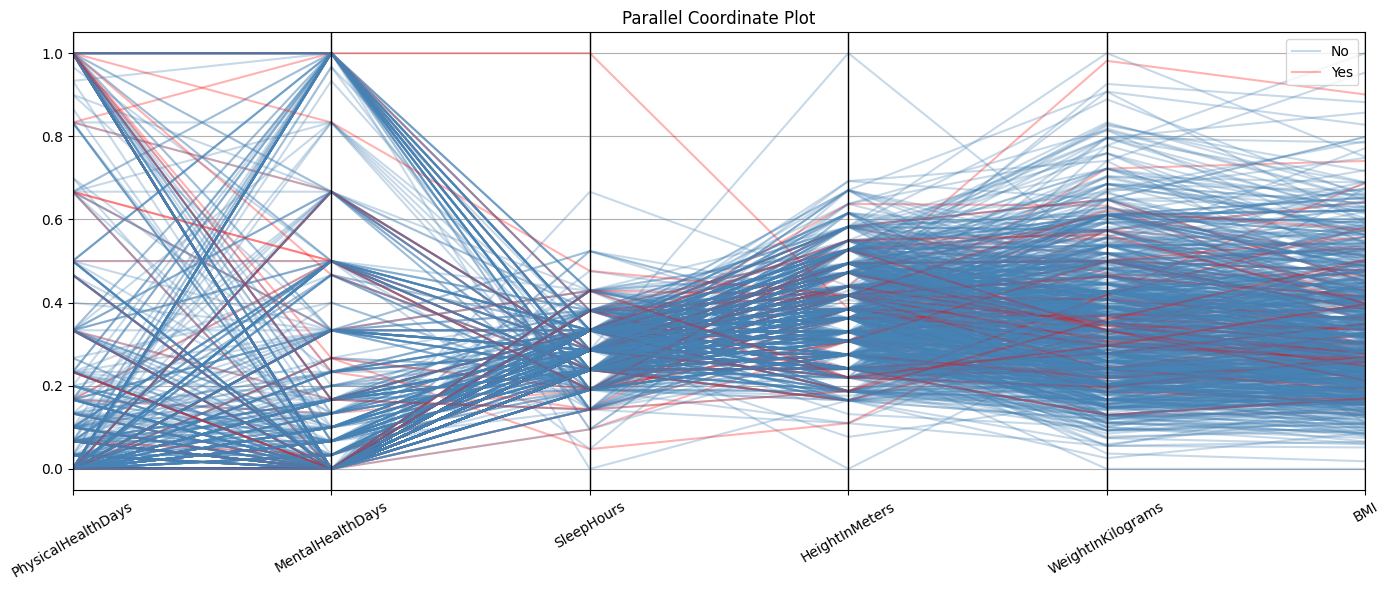

In [17]:
from pandas.plotting import parallel_coordinates

sample_pc = data[numeric_cols + ['HadHeartAttack']].sample(1000, random_state=42).copy()
sample_pc[numeric_cols] = MinMaxScaler().fit_transform(sample_pc[numeric_cols])

plt.figure(figsize=(14, 6))
parallel_coordinates(sample_pc, 'HadHeartAttack',
                     color=['steelblue', 'red'], alpha=0.3)
plt.xticks(rotation=30)
plt.title('Parallel Coordinate Plot')
plt.tight_layout()
plt.show()

#Multivariate: cluster map

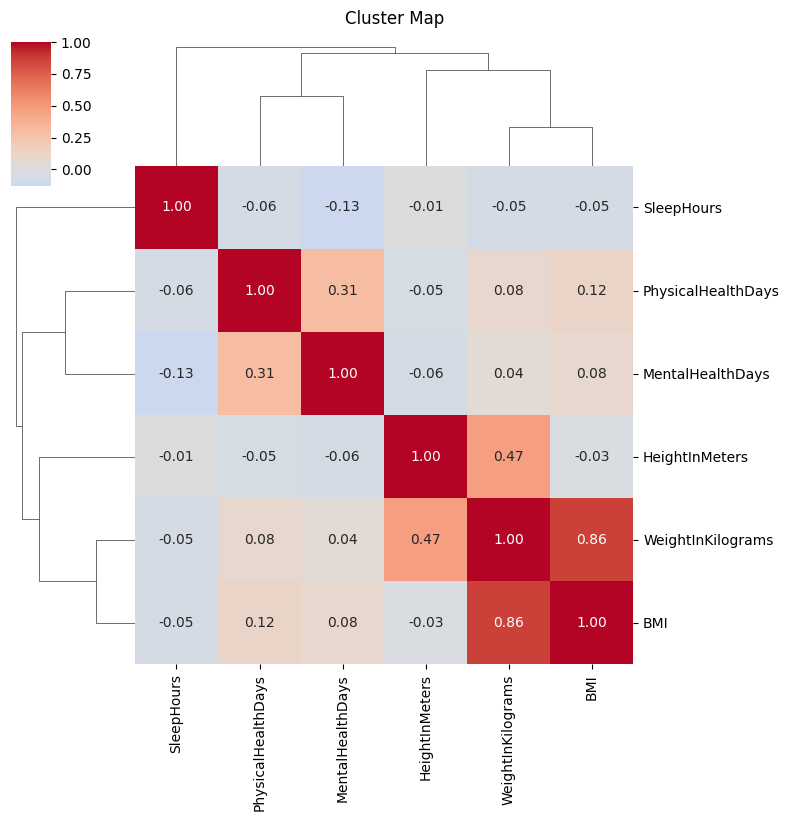

In [18]:
sns.clustermap(data[numeric_cols].corr(), annot=True, fmt='.2f',
               cmap='coolwarm', center=0, figsize=(8, 8))
plt.suptitle('Cluster Map', y=1.02)
plt.show()

#Correlation with target

In [19]:
temp = data.copy()
temp['HeartAttack_enc'] = (temp['HadHeartAttack'] == 'Yes').astype(int)
data_enc = pd.get_dummies(temp.drop(columns=['HadHeartAttack']), drop_first=True)

corr = data_enc.corr()['HeartAttack_enc'] \
               .drop('HeartAttack_enc') \
               .sort_values(ascending=False)

print("Top 10 positively correlated:")
print(corr.head(10))
print("\nTop 10 negatively correlated:")
print(corr.tail(10))

del temp, data_enc

Top 10 positively correlated:
HadAngina_Yes            0.445903
HadStroke_Yes            0.177137
ChestScan_Yes            0.167760
DifficultyWalking_Yes    0.159878
HadDiabetes_Yes          0.145868
GeneralHealth_Poor       0.140607
PhysicalHealthDays       0.133420
HadCOPD_Yes              0.133223
RemovedTeeth_All         0.120564
PneumoVaxEver_Yes        0.119955
Name: HeartAttack_enc, dtype: float64

Top 10 negatively correlated:
LastCheckupTime_Within past 2 years (1 year but less than 2 years ago)   -0.041811
AgeCategory_Age 25 to 29                                                 -0.048216
AgeCategory_Age 40 to 44                                                 -0.049331
AgeCategory_Age 30 to 34                                                 -0.050453
AgeCategory_Age 35 to 39                                                 -0.051119
AlcoholDrinkers_Yes                                                      -0.074181
PhysicalActivities_Yes                                         

#Encode X and define y

In [20]:
#  Target
y = (data['HadHeartAttack'] == 'Yes').astype(int)

#  Drop target from features
df = data.drop(columns=['HadHeartAttack']).copy()

#  Binary columns
binary_cols = ['HadStroke', 'DifficultyWalking', 'AlcoholDrinkers',
               'PhysicalActivities', 'HadAsthma', 'HadKidneyDisease',
               'HadSkinCancer', 'HadAngina', 'ChestScan',
               'FluVaxLast12', 'PneumoVaxEver', 'HIVTesting']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 0})

#  Ordinal: AgeCategory
age_order = ['Age 18 to 24', 'Age 25 to 29', 'Age 30 to 34', 'Age 35 to 39',
             'Age 40 to 44', 'Age 45 to 49', 'Age 50 to 54', 'Age 55 to 59',
             'Age 60 to 64', 'Age 65 to 69', 'Age 70 to 74', 'Age 75 to 79',
             'Age 80 or older']
df['AgeCategory'] = (df['AgeCategory'].astype('category')
                     .cat.set_categories(age_order, ordered=True).cat.codes)

#  Ordinal: GeneralHealth
health_order = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']
df['GeneralHealth'] = (df['GeneralHealth'].astype('category')
                       .cat.set_categories(health_order, ordered=True).cat.codes)

#  One-hot encode remaining object columns
object_cols = df.select_dtypes(include='object').columns.tolist()
X = pd.get_dummies(df, columns=object_cols, drop_first=True)

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

X shape: (246022, 107)
y distribution:
HadHeartAttack
0    232587
1     13435
Name: count, dtype: int64


#Feature selection

#Mutual Information — numeric

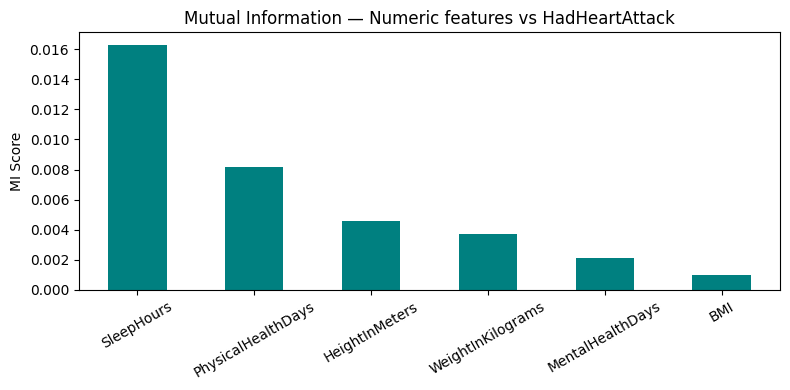

In [21]:
numeric_cols_fs = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours',
                   'HeightInMeters', 'WeightInKilograms', 'BMI']
cat_cols_fs = [c for c in X.columns if c not in numeric_cols_fs]

mi_num = mutual_info_classif(X[numeric_cols_fs], y, random_state=42)
mi_num_scores = pd.Series(mi_num, index=numeric_cols_fs).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
mi_num_scores.plot(kind='bar', color='teal')
plt.title('Mutual Information — Numeric features vs HadHeartAttack')
plt.ylabel('MI Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


#Mutual Information (categorical)

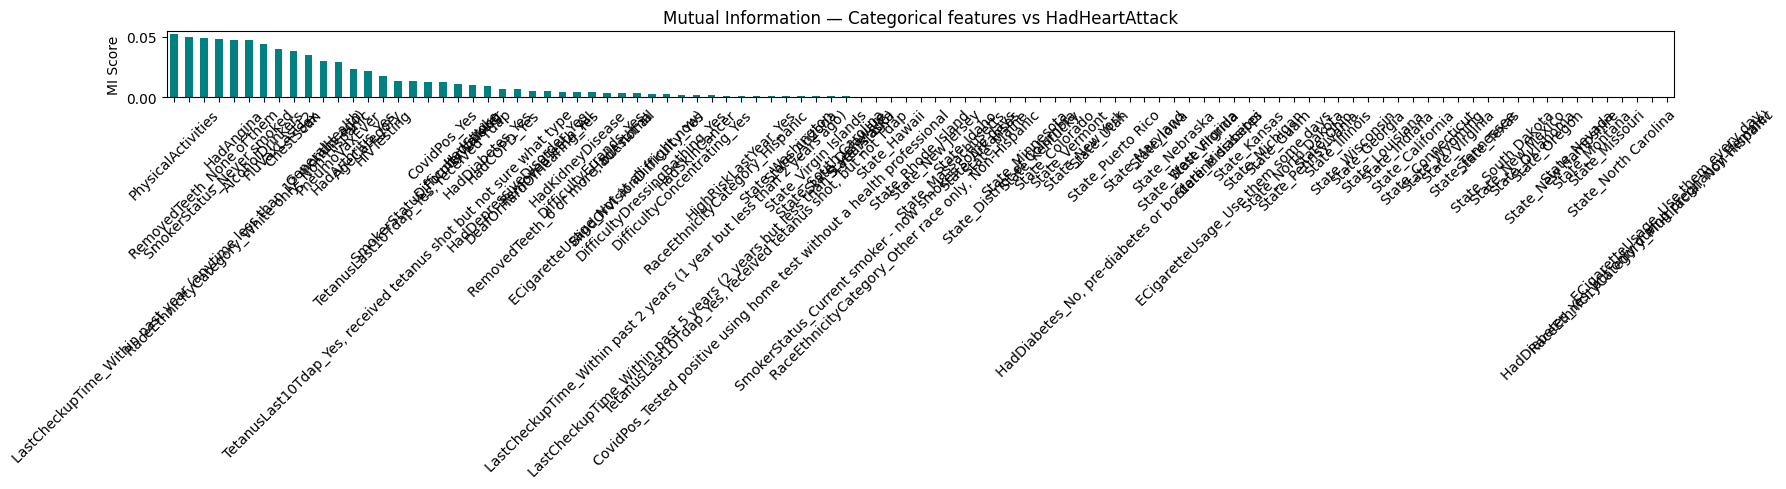

In [22]:
mi_cat = mutual_info_classif(X[cat_cols_fs], y, random_state=42)
mi_cat_scores = pd.Series(mi_cat, index=cat_cols_fs).sort_values(ascending=False)

plt.figure(figsize=(18, 5))
mi_cat_scores.plot(kind='bar', color='teal')
plt.title('Mutual Information — Categorical features vs HadHeartAttack')
plt.ylabel('MI Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#ANOVA F-test (numeric only)

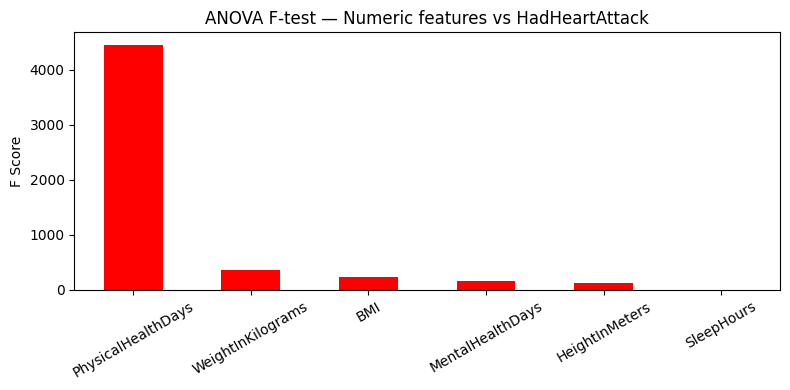

In [23]:
f_num, _ = f_classif(X[numeric_cols_fs], y)
f_scores = pd.Series(f_num, index=numeric_cols_fs).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
f_scores.plot(kind='bar', color='red')
plt.title('ANOVA F-test — Numeric features vs HadHeartAttack')
plt.ylabel('F Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#Chi-square (categorical only)

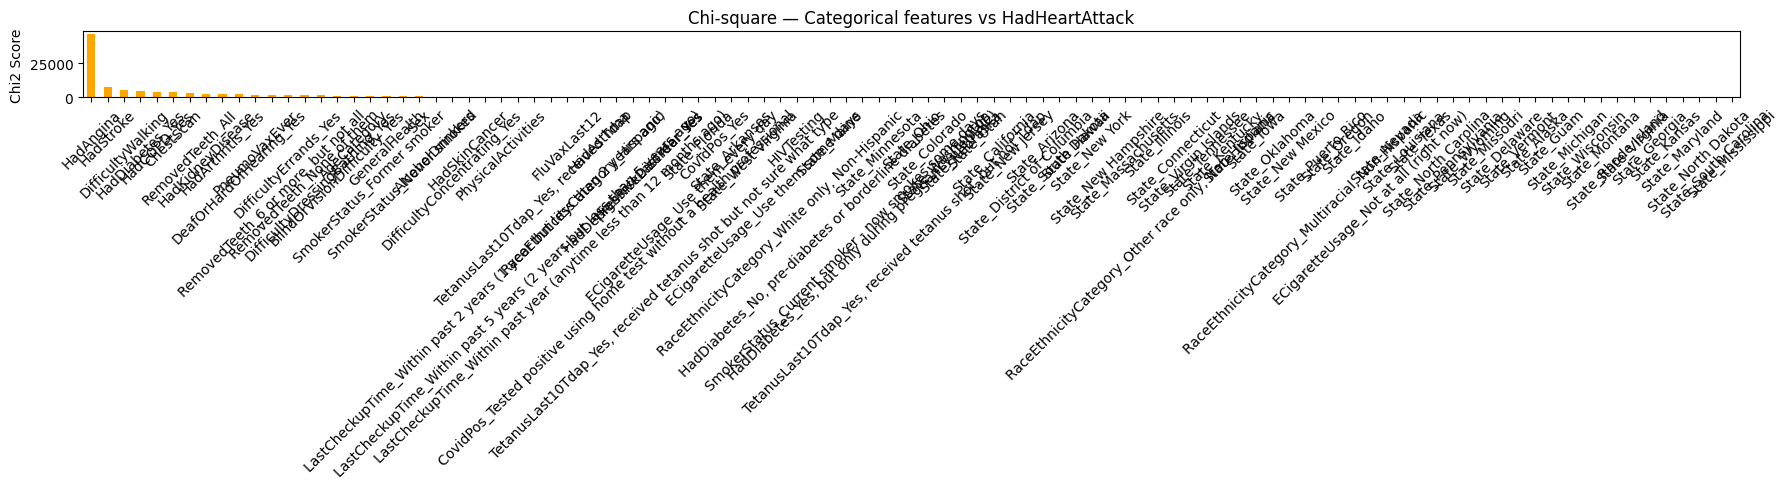

In [24]:
X_cat_scaled = MinMaxScaler().fit_transform(X[cat_cols_fs])
chi2_cat, _ = chi2(X_cat_scaled, y)
chi2_scores = pd.Series(chi2_cat, index=cat_cols_fs).sort_values(ascending=False)

plt.figure(figsize=(18, 5))
chi2_scores.plot(kind='bar', color='orange')
plt.title('Chi-square — Categorical features vs HadHeartAttack')
plt.ylabel('Chi2 Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
num_scores = pd.DataFrame({
    'feature': numeric_cols_fs, 'type': 'numeric',
    'MI': mi_num, 'F_ANOVA': f_num, 'Chi2': np.nan
})

cat_scores = pd.DataFrame({
    'feature': cat_cols_fs, 'type': 'categorical',
    'MI': mi_cat, 'F_ANOVA': np.nan, 'Chi2': chi2_cat
})

all_scores = pd.concat([num_scores, cat_scores], ignore_index=True)
for col in ['MI', 'F_ANOVA', 'Chi2']:
    mn, mx = all_scores[col].min(), all_scores[col].max()
    all_scores[col + '_norm'] = (all_scores[col] - mn) / (mx - mn)

all_scores['composite'] = all_scores[
    ['MI_norm', 'F_ANOVA_norm', 'Chi2_norm']
].mean(axis=1, skipna=True)

all_scores = all_scores.sort_values('composite', ascending=False).reset_index(drop=True)
all_scores['rank'] = all_scores.index + 1

print(all_scores[['rank', 'feature', 'type', 'composite']].to_string(index=False))

selected_features = all_scores[all_scores['composite'] >= 0.03]['feature'].tolist()
X_selected = X[selected_features]
print(f"\nFeatures kept: {len(selected_features)} / {X.shape[1]}")
print(selected_features)

 rank                                                                 feature        type    composite
    1                                                               HadAngina categorical 9.576303e-01
    2                                                      PhysicalHealthDays     numeric 5.792782e-01
    3                                                      PhysicalActivities categorical 5.041199e-01
    4                                               RemovedTeeth_None of them categorical 4.914797e-01
    5      LastCheckupTime_Within past year (anytime less than 12 months ago) categorical 4.856644e-01
    6                                               SmokerStatus_Never smoked categorical 4.773076e-01
    7                          RaceEthnicityCategory_White only, Non-Hispanic categorical 4.527362e-01
    8                                                         AlcoholDrinkers categorical 4.328311e-01
    9                                                               Chest

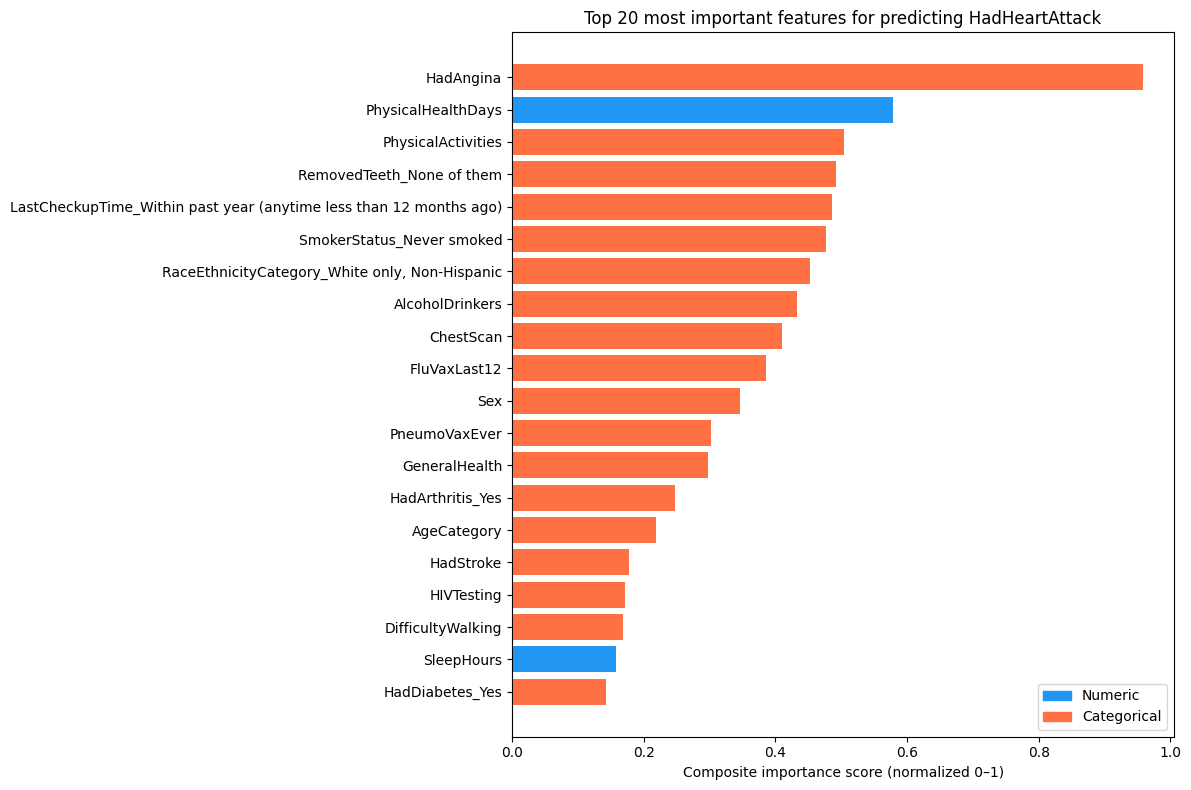


Features kept: 39 / 107
['HadAngina', 'PhysicalHealthDays', 'PhysicalActivities', 'RemovedTeeth_None of them', 'LastCheckupTime_Within past year (anytime less than 12 months ago)', 'SmokerStatus_Never smoked', 'RaceEthnicityCategory_White only, Non-Hispanic', 'AlcoholDrinkers', 'ChestScan', 'FluVaxLast12', 'Sex', 'PneumoVaxEver', 'GeneralHealth', 'HadArthritis_Yes', 'AgeCategory', 'HadStroke', 'HIVTesting', 'DifficultyWalking', 'SleepHours', 'HadDiabetes_Yes', 'SmokerStatus_Former smoker', 'TetanusLast10Tdap_Yes, received tetanus shot but not sure what type', 'TetanusLast10Tdap_Yes, received Tdap', 'CovidPos_Yes', 'HadCOPD_Yes', 'RemovedTeeth_All', 'DeafOrHardOfHearing_Yes', 'WeightInKilograms', 'HadKidneyDisease', 'HadDepressiveDisorder_Yes', 'RemovedTeeth_6 or more, but not all', 'DifficultyErrands_Yes', 'HeightInMeters', 'BlindOrVisionDifficulty_Yes', 'DifficultyDressingBathing_Yes', 'MentalHealthDays', 'ECigaretteUsage_Not at all (right now)', 'HadAsthma', 'BMI']


In [26]:
top20 = all_scores.head(20)
colors = ['#2196F3' if t == 'numeric' else '#FF7043' for t in top20['type']]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top20['feature'][::-1], top20['composite'][::-1], color=colors[::-1])
ax.set_xlabel('Composite importance score (normalized 0–1)')
ax.set_title('Top 20 most important features for predicting HadHeartAttack')
ax.legend(handles=[Patch(color='#2196F3', label='Numeric'),
                   Patch(color='#FF7043', label='Categorical')], loc='lower right')
plt.tight_layout()
plt.show()

# Filter to selected features
selected_features = all_scores[all_scores['composite'] >= 0.03]['feature'].tolist()
X_selected = X[selected_features]
print(f"\nFeatures kept: {len(selected_features)} / {X.shape[1]}")
print(selected_features)

#Train CatBoost Model

In [27]:
import lightgbm as lgb

In [28]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.6 MB/s eta 0:00:00


In [30]:
from catboost import CatBoostClassifier

cat_features = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.20, random_state=42, stratify=y)

model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test)
)

0:	test: 0.8441516	best: 0.8441516 (0)	total: 241ms	remaining: 2m
100:	test: 0.8865565	best: 0.8865723 (99)	total: 18.8s	remaining: 1m 14s
200:	test: 0.8875444	best: 0.8875699 (186)	total: 28.9s	remaining: 43s
300:	test: 0.8879144	best: 0.8879321 (299)	total: 35.6s	remaining: 23.5s
400:	test: 0.8879290	best: 0.8879542 (347)	total: 40.7s	remaining: 10s
499:	test: 0.8877571	best: 0.8879542 (347)	total: 47.4s	remaining: 0us

bestTest = 0.8879541977
bestIteration = 347

Shrink model to first 348 iterations.


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=500, learning_rate=0.05, loss_function='Logloss', verbose=100)

#Evaluation: classification report & confusion matrix

In [31]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97     46518
           1       0.59      0.23      0.33      2687

    accuracy                           0.95     49205
   macro avg       0.77      0.61      0.65     49205
weighted avg       0.94      0.95      0.94     49205

AUC: 0.887954197688389


#Evaluation: ROC & Precision-Recall curves

ROC-AUC Score : 0.8880
PR-AUC Score  : 0.4124


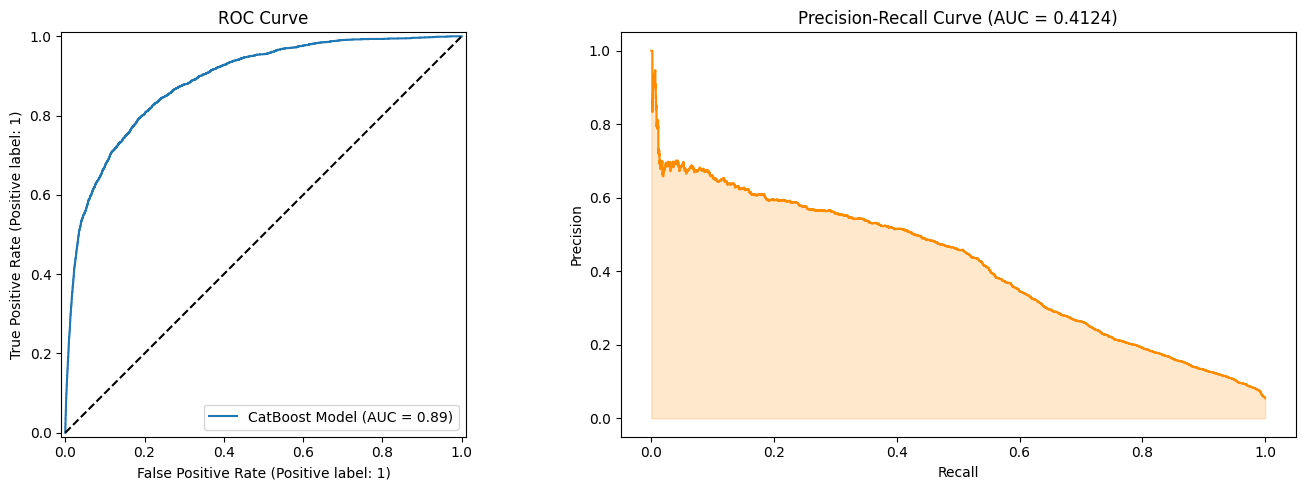

In [32]:
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"PR-AUC Score  : {pr_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name='CatBoost Model')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curve')

axes[1].plot(recall, precision, color='darkorange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
axes[1].fill_between(recall, precision, alpha=0.2, color='darkorange')

plt.tight_layout()
plt.show()

#SHAP

In [33]:
import shap

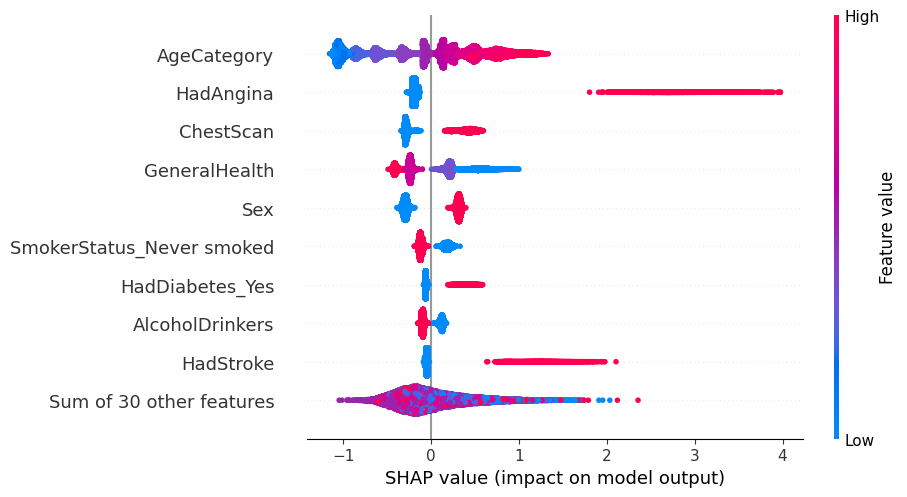

In [34]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

#LIME

In [35]:
X_train_np = X_train.copy()
X_test_np = X_test.copy()

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_np),
    feature_names=X.columns,
    class_names=['No Heart Attack', 'Heart Attack'],
    categorical_features=[X.columns.get_loc(col) for col in cat_features],
    mode='classification'
)

i = 0

exp = lime_explainer.explain_instance(
    data_row=X_test_np.iloc[i],
    predict_fn=model.predict_proba
)

exp.show_in_notebook(show_table=True)